TokaMaker Example: Predicting currents and forces induced during a CQ in ITER {#doc_tMaker_ITER_ex5}
==========
In this example we show how to compute eddy currents and resulting forces from a simplified disruptive current quench in ITER. 

This example utilizes the mesh built in \ref doc_tMaker_ITER_ex1.

**Note:** Running this example requires the [h5py](https://www.h5py.org/) python package, which is installable using `pip` or other standard methods.

To load the TokaMaker python module we need to tell python where to the module is located. The best way to do this is through the `PYTHONPATH` environment variable or using a dedicated environement variable (eg. `OFT_ROOTPATH`) to provide the path to where the OpenFUSIONToolkit is installed and passing this to `sys.path.append()` as below.

It is also possible to run this script on Google Colab, which requires a few other steps including installing OFT from a binary tarball.

In [1]:
import os
try:
    from google.colab import output
    output.enable_custom_widget_manager()
    on_google_colab = True
except:
    import sys
    tokamaker_python_path = os.getenv('OFT_ROOTPATH')
    if tokamaker_python_path is not None:
        sys.path.append(os.path.join(tokamaker_python_path,'python'))
    on_google_colab = False
    pass
else:
    %cd /content
    !pip install -q wurlitzer ipympl openfusiontoolkit
    if not os.path.exists('OpenFUSIONToolkit-Tutorials/OSSFE-2026'):
        !git clone -b MiRACL26 --single-branch --depth 1 https://github.com/OpenFUSIONToolkit/OpenFUSIONToolkit-Tutorials
        #!git clone --depth 1 https://github.com/OpenFUSIONToolkit/OpenFUSIONToolkit-Tutorials
    %cd OpenFUSIONToolkit-Tutorials/MiRACL-2026
    print("Google collab detected:")
    %load_ext wurlitzer
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [3]:
import urllib.request

def fetch_file(url,filename=None):
    if filename is None:
        filename=url.split('/')[-1]
    print(f'Fetching {url}')
    with urllib.request.urlopen(f'{url}') as response:
        with open(filename, "wb") as handle:
            handle.write(response.read())
    print('  Done')

fetch_file('https://raw.githubusercontent.com/OpenFUSIONToolkit/OpenFUSIONToolkit/main/src/examples/TokaMaker/SPARC/sparc_public_mesh.h5')
fetch_file('https://raw.githubusercontent.com/cfs-energy/SPARCPublic/main/PrimaryReferenceDischarge/2%20-%20SPARC_DN_PRD_freegs_20221013','gSPARC')

Fetching https://raw.githubusercontent.com/OpenFUSIONToolkit/OpenFUSIONToolkit/main/src/examples/TokaMaker/SPARC/sparc_public_mesh.h5
  Done
Fetching https://raw.githubusercontent.com/cfs-energy/SPARCPublic/main/PrimaryReferenceDischarge/2%20-%20SPARC_DN_PRD_freegs_20221013
  Done


## Load TokaMaker library

To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

For meshing we will use the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain "gs_Domain" class to build a 2D triangular grid suitable for Grad-Shafranov equilibria. This class uses the [triangle code](https://www.cs.cmu.edu/~quake/triangle.html) through a [python wrapper](https://pypi.org/project/triangle/).

In [4]:
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk, compute_forces_components

In [5]:
if on_google_colab:
    myOFT = OFT_env(nthreads=1)
else:
    myOFT = OFT_env(nthreads=2)

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Base release:        v26.6
Development branch:  main
Revision id:         3db6ce30

Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2

Linear Algebra backend: native

#----------------------------------------------



## Compute pre-CQ equilibrium
Now we compute the same equilibrium as in \ref doc_tMaker_ITER_ex2.

In [6]:
# Initialize OFT environment
mygs = TokaMaker(myOFT)

In [7]:
# Load SPARC EQDSK
eqdsk = read_eqdsk('gSPARC')

# Load mesh into TokaMaker
mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('sparc_public_mesh.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.setup(order=2,F0=eqdsk['rcentr']*eqdsk['bcentr'])

# Define a vertical stability coil
mygs.set_coil_vsc({'VS1U': 1.0, 'VS1L': -1.0})

# Define global targets
mygs.set_targets(Ip=abs(eqdsk['ip']), Ip_ratio=2.25)

# Define shape targets
isoflux_pts = eqdsk['rzout'].copy()
mygs.set_isoflux_constraints(isoflux_pts)
x_point_upper = isoflux_pts[np.argmax(isoflux_pts[:,1])]
x_point_lower = np.array([x_point_upper[0], -x_point_upper[1]])
saddle_pts = np.array([x_point_upper, x_point_lower])
mygs.set_saddle_constraints(saddle_pts)

# Set coil regularization matrix
regularization_terms = []
for name, coil in mygs.coil_sets.items():
    if name.startswith('VS'):
        regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=0.0,weight=1.E2))
    else:
        regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=0.0,weight=1.E0))
regularization_terms.append(mygs.coil_reg_term({'#VSC': 1.0},target=0.0,weight=1.E2))
mygs.set_coil_reg(reg_terms=regularization_terms)

# Set F*F' and P' profiles
ffprim = eqdsk['ffprim']
pprime = eqdsk['pprime']

psi_eqdsk = np.linspace(0.0,1.0,np.size(ffprim))
psi_sample = np.linspace(0.0,1.0,50)

ffp_prof = np.interp(psi_sample,psi_eqdsk,ffprim)
pp_prof = np.interp(psi_sample,psi_eqdsk,pprime)

mygs.set_profiles(ffp_prof={'type': 'linterp', 'y': ffp_prof, 'x': psi_sample},
                  pp_prof={'type': 'linterp', 'y': pp_prof, 'x': psi_sample})

# Compute equilibrium
R0 = 1.85
Z0 = 0.0
a = 0.5*(isoflux_pts[:,0].max() - isoflux_pts[:,0].min())
kappa = (isoflux_pts[:,1].max() - isoflux_pts[:,1].min())/(2.0*a)
delta = (R0 - x_point_upper[0])/a
mygs.init_psi(R0, Z0, a, kappa, delta)
vde_eq = mygs.solve()

#
psi_full = mygs.get_psi(normalized=False)
psi_lim = mygs.psi_bounds[0]


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  2.900E+01
    # of points  =   18989
    # of edges   =   56604
    # of cells   =   37616
    # of boundary points =     360
    # of boundary edges  =     360
    # of boundary cells  =     360
  Resolution statistics:
    hmin =  1.000E-03
    hrms =  4.468E-02
    hmax =  9.258E-02
  Surface grounded at vertex    3175


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    1.4699000000000000E-002
Starting non-linear GS solver
     1  1.6548E+00  1.0954E-06  1.9274E-01  1.8913E+00  4.9205E-04  1.2349E+01
     2  1.7996E+00  1.1842E-06  7.2529E-02  1.8906E+00  1.0701E-03  9.0423E+00
     3  1.8654E+00  1.2243E-06  2.8890E-02  1.8907E+00  1.2928E-03  6.7538E+00
     4  1.8999E+00  1.2452E-06  1.3194E-02  1.8909E+00  1.3453E-03  5.4442E+00
     5  1.9186E+00  1.2564E-06

### Print information and plot equilibrium
Flux surfaces of the computed equilibrium can be plotted using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_psi "plot_psi()" method. The additional plotting methods \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_machine "plot_machine()" and \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_constraints "plot_constraints()" are also used to show context and other information. Each method has a large number of optional arguments for formatting and other options.

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    8.7000E+06
  Current Centroid [m]    =    1.843  0.001
  Magnetic Axis [m]       =    1.892  0.001
  Elongation              =    1.967 (U:  1.990, L:  1.945)
  Triangularity           =    0.559 (U:  0.570, L:  0.548)
  Plasma Volume [m^3]     =   20.215
  q_0, q_95               =    0.949  3.167
  Plasma Pressure [Pa]    =   Axis:  2.6064E+06, Peak:  2.6064E+06
  Stored Energy [J]       =    1.8282E+07
  <Beta_pol> [%]          =   36.5108
  <Beta_tor> [%]          =    1.0265
  <Beta_n>   [%]          =    0.8147
  Diamagnetic flux [Wb]   =    2.3614E-01
  Toroidal flux [Wb]      =    2.3108E+01
  l_i                     =    1.2881

Coil Currents [MA]:
  CS1UI:          -0.07
  CS1UO:          -0.05
  CS1LI:          -0.07
  CS1LO:          -0.05
  CS2U:           -0.03
  CS2L:           -0.03
  CS3U:            0.02
  CS3L:            0.02
  PF1U:            0.03
  PF1L:            0.03


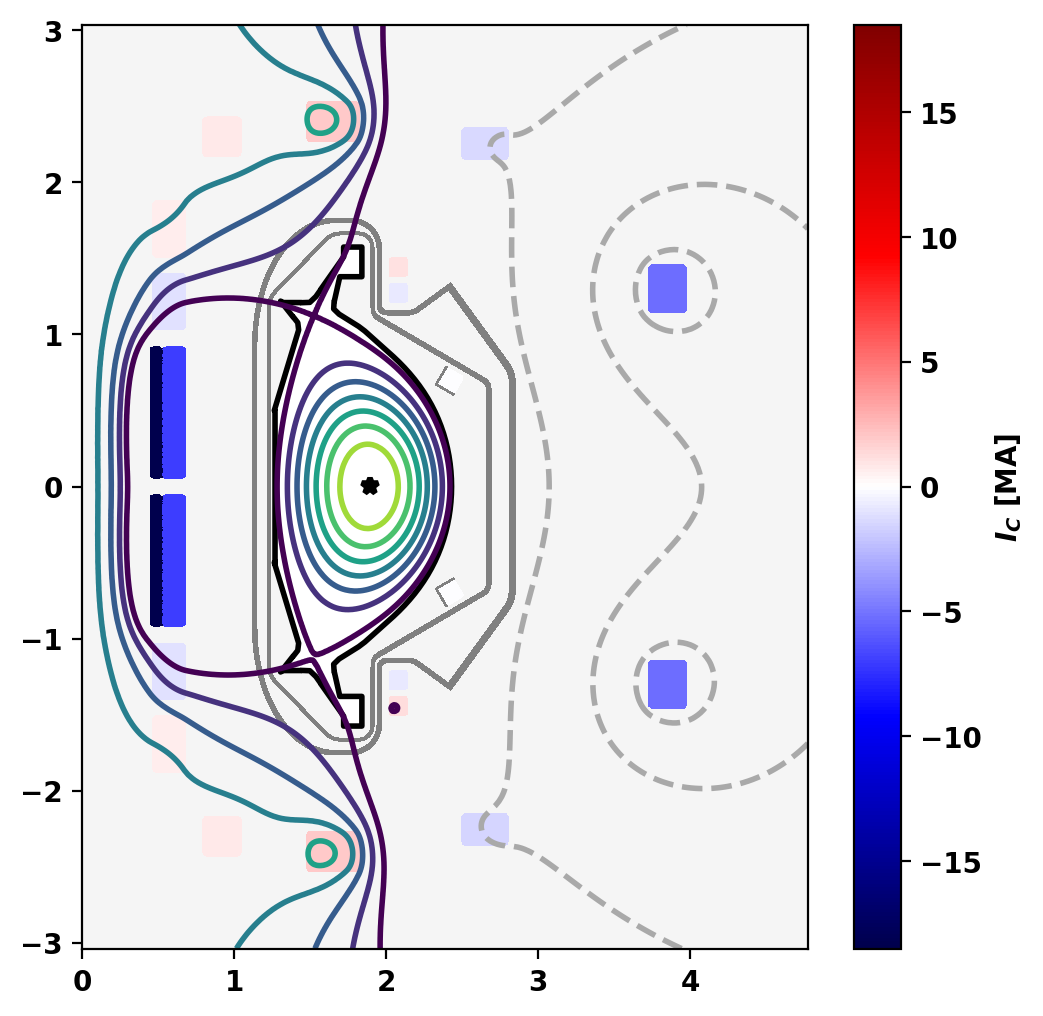

In [8]:
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_symmap=True,coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]')
mygs.plot_psi(fig,ax,xpoint_color=None,vacuum_nlevels=4)

mygs.print_info()
print()
print("Coil Currents [MA]:")
coil_currents, _ = mygs.get_coil_currents()
for key, current in coil_currents.items():
    print('  {0:10} {1:10.2F}'.format(key+":",current/1.E6))

## Compute eddy currents and forces for a simple current quench
TokaMaker can be used to evaluate some of the impacts caused by the Current Quench (CQ) that occurs following a disruption in tokamaks. During the CQ the plasma current rapidly falls due to high resistivity following the thermal quench. In real CQs the plasma current profile significantly evolves during this quench, due to changes in pressure and temperature profiles and plasma motions, such as VDEs. However, for first order approximation we can model the eddy currents and voltages produced by the CQ by simply decreasing the flux corresponding to the plasma current over a given timescale.

### Extract flux from plasma current only
To do this we first need to separate the flux corresponding to the plasma current, which changes during the CQ, from the vacuum flux produced by the coils, which does not change (if the coil currents remain fixed) over the CQ. This can be done by performing a vacuum solve (\ref OpenFUSIONToolkit.TokaMaker.TokaMaker.vac_solve "vac_solve()") to get the vacuum flux from the coils and then subtracting this from the full flux to isolate the plasma contribution.

**Note:** This is meant to act as a first order model of inductive CQ impacts and additional effects related to the detailed evolution of the plasma current, coil currents, and other dynamics will be important for detailed analysis and/or predicitons.

Growth rate = 6.7112E+01 [s^-1]
Growth time = 1.4900E-02 [s]


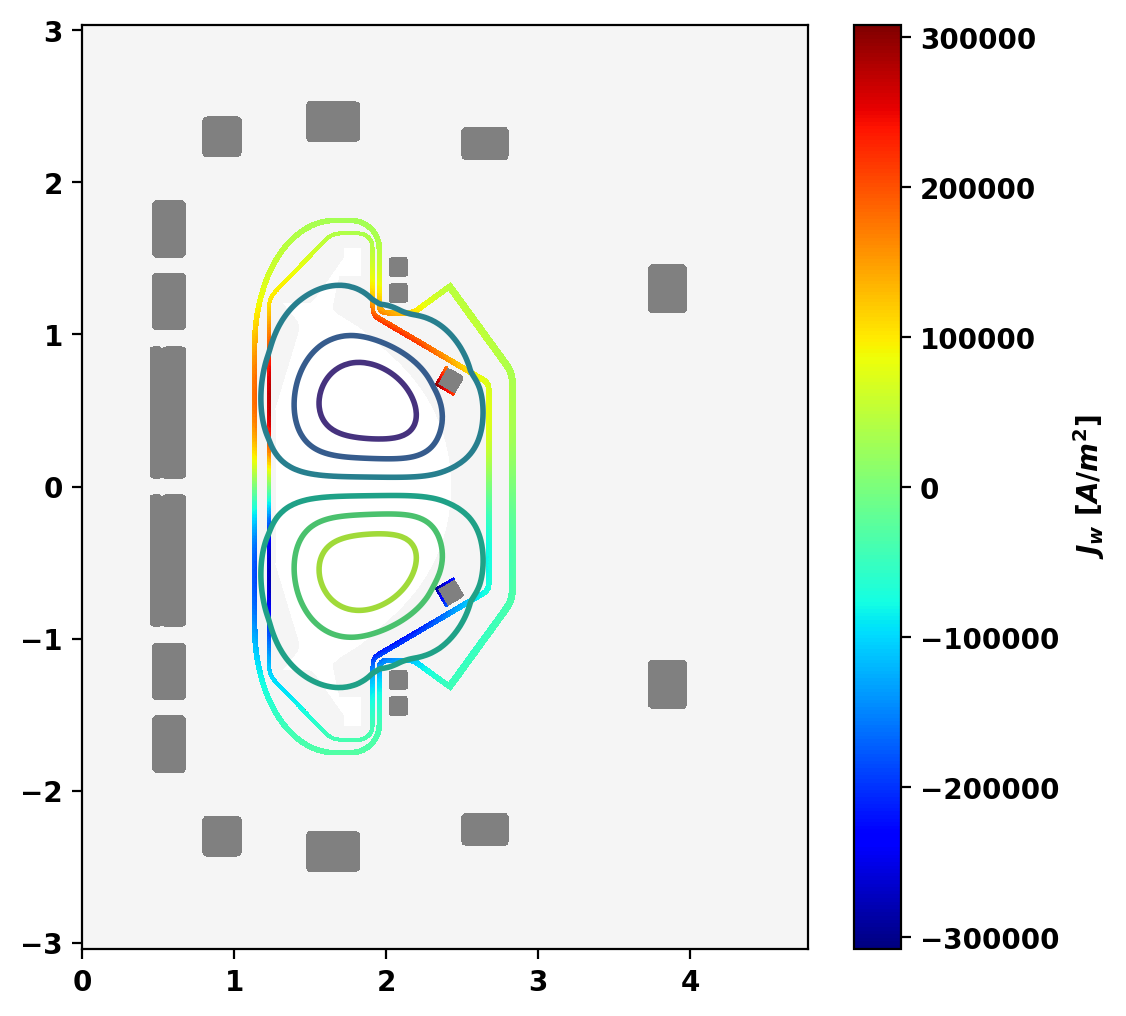

In [9]:
growth_rates, eig_modes = mygs.compute_linear_stability(5.E3,10,False) 
fig, ax = plt.subplots()
mygs.plot_machine(fig,ax,limiter_color=None)
mygs.plot_psi(fig,ax,psi=eig_modes[0,:],normalized=False,xpoint_color=None,opoint_color=None)
mygs.plot_eddy(fig,ax,dpsi_dt=eig_modes[0,:]*abs(growth_rates[0]))
print('Growth rate = {0:.4E} [s^-1]'.format(growth_rates[0]))
print('Growth time = {0:.4E} [s]'.format(1.0/growth_rates[0]))

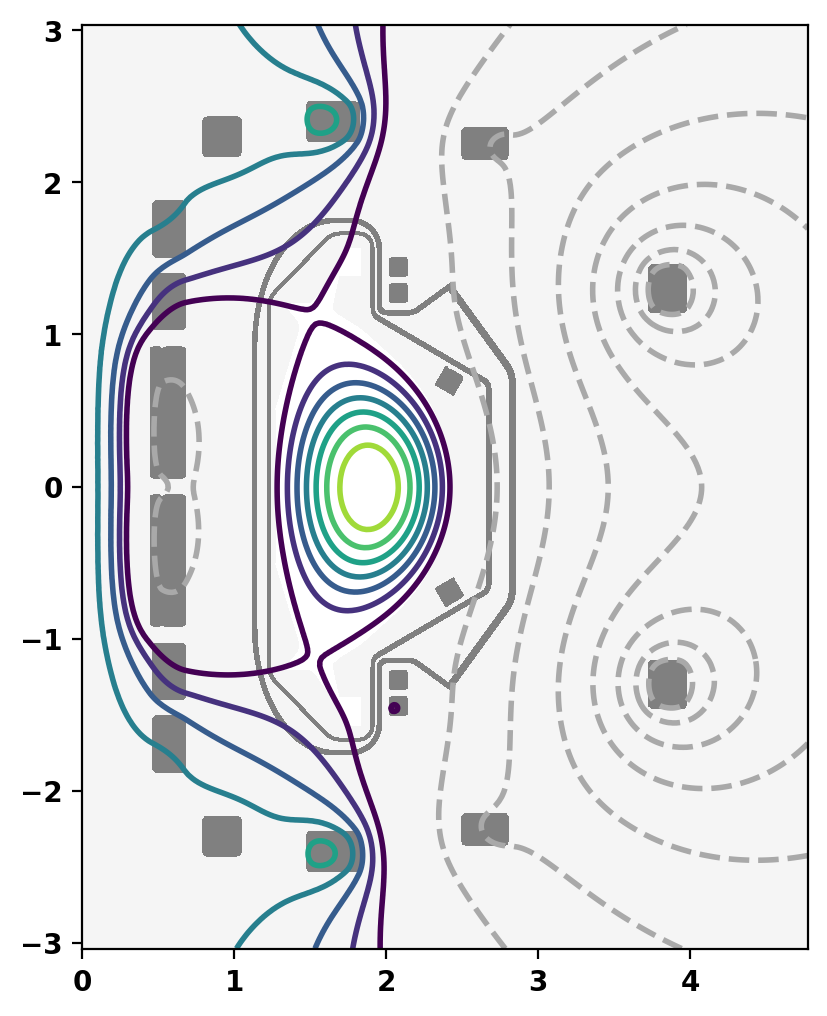

In [10]:
psi0 = vde_eq.get_psi(normalized = False)
max_loc = eig_modes[0,:].argmax()
psi_ic = psi0-np.sign(mygs.r[max_loc,1])*eig_modes[0,:]*(vde_eq.psi_bounds[1]-vde_eq.psi_bounds[0])/eig_modes[0,max_loc]/100.0

fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,limiter_color=None)
mygs.plot_psi(fig,ax,psi=vde_eq.abspsi_to_normalized(psi_ic),xpoint_color=None,opoint_color=None)
mygs.set_psi(psi_ic)

### Perform time-dependent simulation with plasma-current quench source
With the flux separated into constituent components a time-dependent simulation may now be performed to compute the evolution of eddy current in conducting structures in response to the loop voltage generated by the CQ. 

In [11]:
mygs.settings.pm=False
mygs.update_settings()
mygs.set_isoflux_constraints(None)

mygs.setup_td(1.E-03,1.E-13,1.E-11,pre_plasma=False)

In [12]:
import time
sim_time = 0.0
dt = 1.E-1/growth_rates[0]
nplot = 1
nstatus = 2
times = [sim_time]
results = [mygs.copy_eq()]
q95_hist = [results[-1].get_stats()['q_95']]
t00 = time.perf_counter()

Ip_target = eqdsk['ip']
Ip_ratio_target = 2.25
mygs.set_targets(Ip=Ip_target,Ip_ratio=Ip_ratio_target)
Lp, _ = results[-1].calc_inductance()
E0 = 0.5*Lp*np.power(Ip_target,2)

exit_next = False
for i in range(80):
    t0 = time.perf_counter()
    sim_time, _, nl_its, lin_its, nretry = mygs.step_td(sim_time,dt)
    t1 = time.perf_counter()
    if i % nstatus == 0:
        print('{0:.5E} {1:.5E} {2:4d} {3:4d} {5:8.3f} {4:4d}'.format(sim_time,dt,nl_its,lin_its,nretry,t1-t0))
    results.append(mygs.copy_eq())
    times.append(sim_time)
    q95_hist.append(results[-1].get_stats()['q_95'])
    # Exit after TQ
    if Ip_ratio_target > 10.0:
        break
    # Perform TQ when plasma touches the wall or q_95 < 1
    if (not results[-1].diverted) or (q95_hist[-1] < 1.0):
        Ip_ratio_target = 20.0
    # Update plasma Ip target to maintain constant magnetic energy
    Lp, _ = results[-1].calc_inductance()
    Ip_target=np.sqrt(E0*2.0/Lp)
    mygs.set_targets(Ip=Ip_target,Ip_ratio=Ip_ratio_target)
t1 = time.perf_counter()
print('Total time = {0:8.3f}'.format(t1-t00))

1.49004E-03 1.49004E-03    2   20    1.411    0
4.47011E-03 1.49004E-03    3   23    0.355    0
7.45018E-03 1.49004E-03    3   27    0.396    0
1.04303E-02 1.49004E-03    2   19    0.288    0
1.34103E-02 1.49004E-03    3   27    0.389    0
1.63904E-02 1.49004E-03    2   20    0.288    0
1.93705E-02 1.49004E-03    2   20    0.288    0
2.23505E-02 1.49004E-03    3   26    0.378    0
2.53306E-02 1.49004E-03    2   21    0.301    0
2.83107E-02 1.49004E-03    3   25    0.365    0
3.12908E-02 1.49004E-03    3   29    0.412    0
3.42708E-02 1.49004E-03    3   27    0.387    0
3.72509E-02 1.49004E-03    4   33    0.482    0
4.02310E-02 1.49004E-03    3   29    0.412    0
4.32110E-02 1.49004E-03    3   32    0.447    0
Total time =   14.884


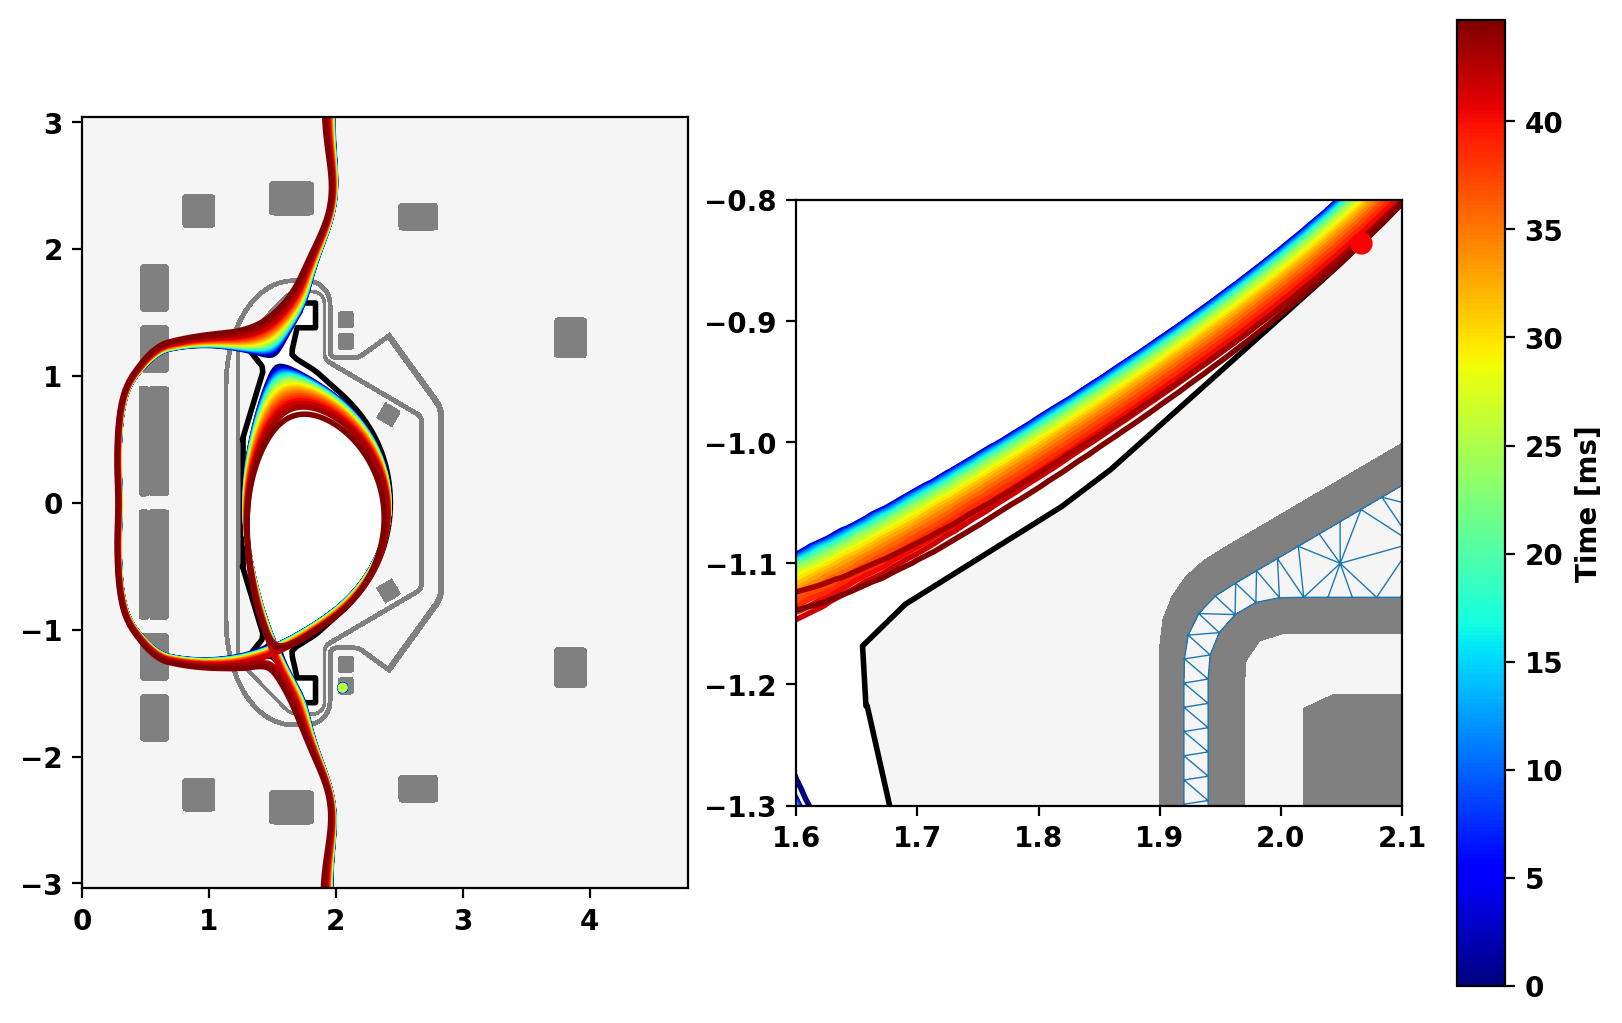

In [13]:
import matplotlib as mpl
fig, ax = plt.subplots(1,2,constrained_layout=True,figsize=(8,5))
mygs.plot_machine(fig,ax[0])
plot_results = results[::nplot]
colors = plt.cm.jet(np.linspace(0,1,len(plot_results)))
for i, result in enumerate(plot_results):
    mygs.plot_psi(fig,ax[0],equilibrium=result,plasma_nlevels=1,plasma_color=[colors[i]], vacuum_nlevels = 0,xpoint_color=None,opoint_color=None)
norm = mpl.colors.Normalize(vmin=0.0, vmax=sim_time*1.E3)
mygs.plot_machine(fig,ax[1])
for i, result in enumerate(plot_results):
    mygs.plot_psi(fig,ax[1],equilibrium=result,plasma_nlevels=1,plasma_color=[colors[i]], vacuum_nlevels = 0,xpoint_color=None,opoint_color=None)
last_eq = plot_results[-1]
ax[1].plot(last_eq.lim_point[0],last_eq.lim_point[1],'ro')
ax[1].triplot(mesh_pts[:,0],mesh_pts[:,1],mesh_lc[mesh_reg==3,:],lw=0.5,label=key)
_ = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=plt.cm.jet),ax=ax[1],label='Time [ms]')
ax[1].set_ylim(-1.3,-0.8)
_ =ax[1].set_xlim(1.6,2.1)

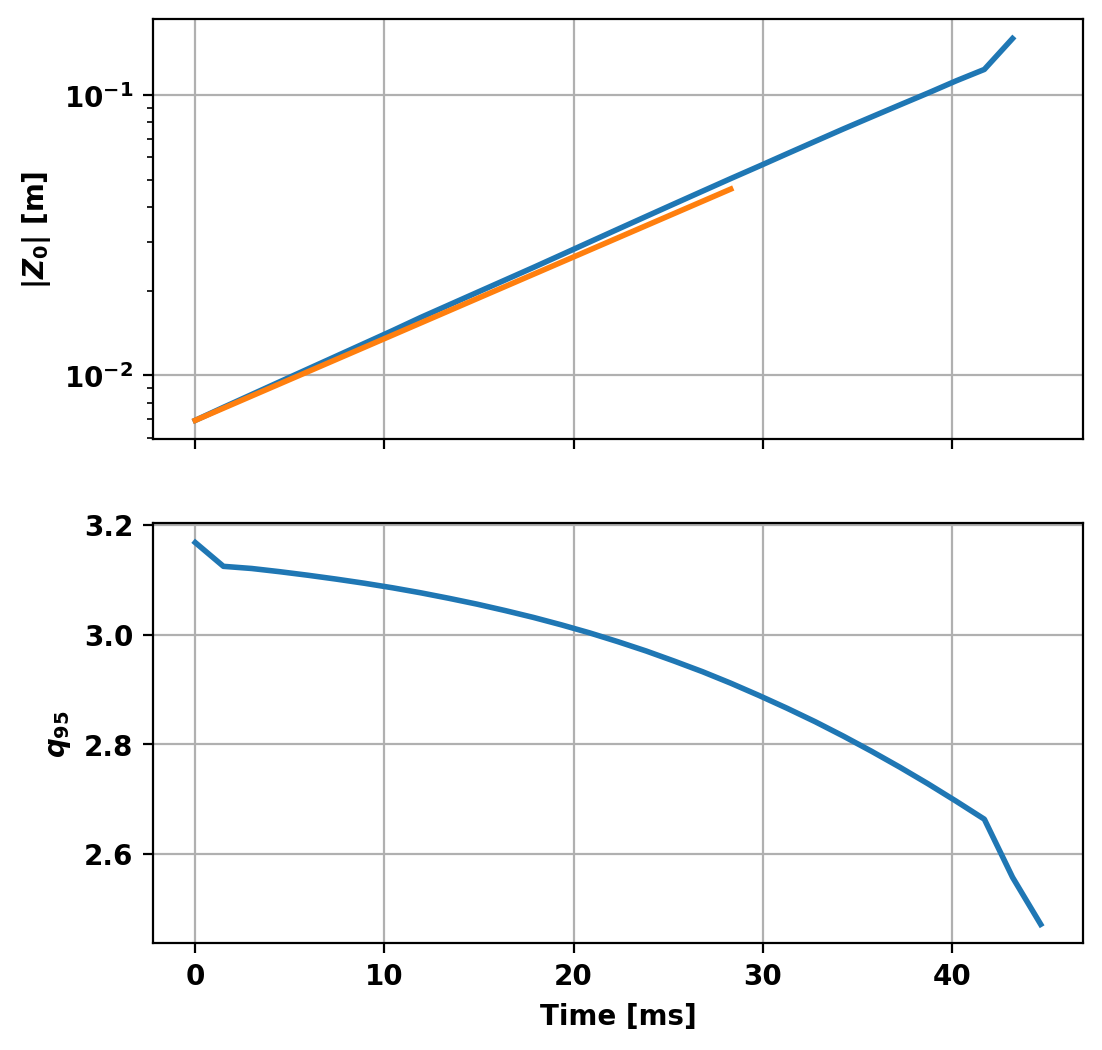

In [14]:
fig, ax = plt.subplots(2,1,sharex=True)
z0 = [[times[i], results[i].o_point[1]] for i in range(len(results))]
z_hist = np.asarray(z0); z_hist = z_hist[1:,:] - [z_hist[1,0], z_hist[0,1]]
ax[0].semilogy(z_hist[:,0]*1.E3,abs(z_hist[:,1]))
ax[0].semilogy(z_hist[:20,0]*1.E3,abs(z_hist[0,1])*np.exp(z_hist[:20,0]*growth_rates[0]))
ax[0].set_ylabel(r'$|Z_0|$ [m]')
ax[0].grid(True)
q_hist = np.asarray([[times[i], q95] for i, q95 in enumerate(q95_hist)])
# eig_comp = [[times[i], np.dot(eig_modes[0,:],results[i].get_psi(False)-psi0)] for i in range(len(results))]
# eig_hist = np.asarray(eig_comp); eig_hist = eig_hist[1:,:]
ax[1].plot(q_hist[:,0]*1.E3,q_hist[:,1])
# ax[1].semilogy(eig_hist[:20,0]*1.E3,abs(eig_hist[0,1])*np.exp(eig_hist[:20,0]*growth_rates[0]))
ax[1].set_ylabel(r'$q_{95}$')
ax[1].grid(True)
_ = ax[-1].set_xlabel(r'Time [ms]')

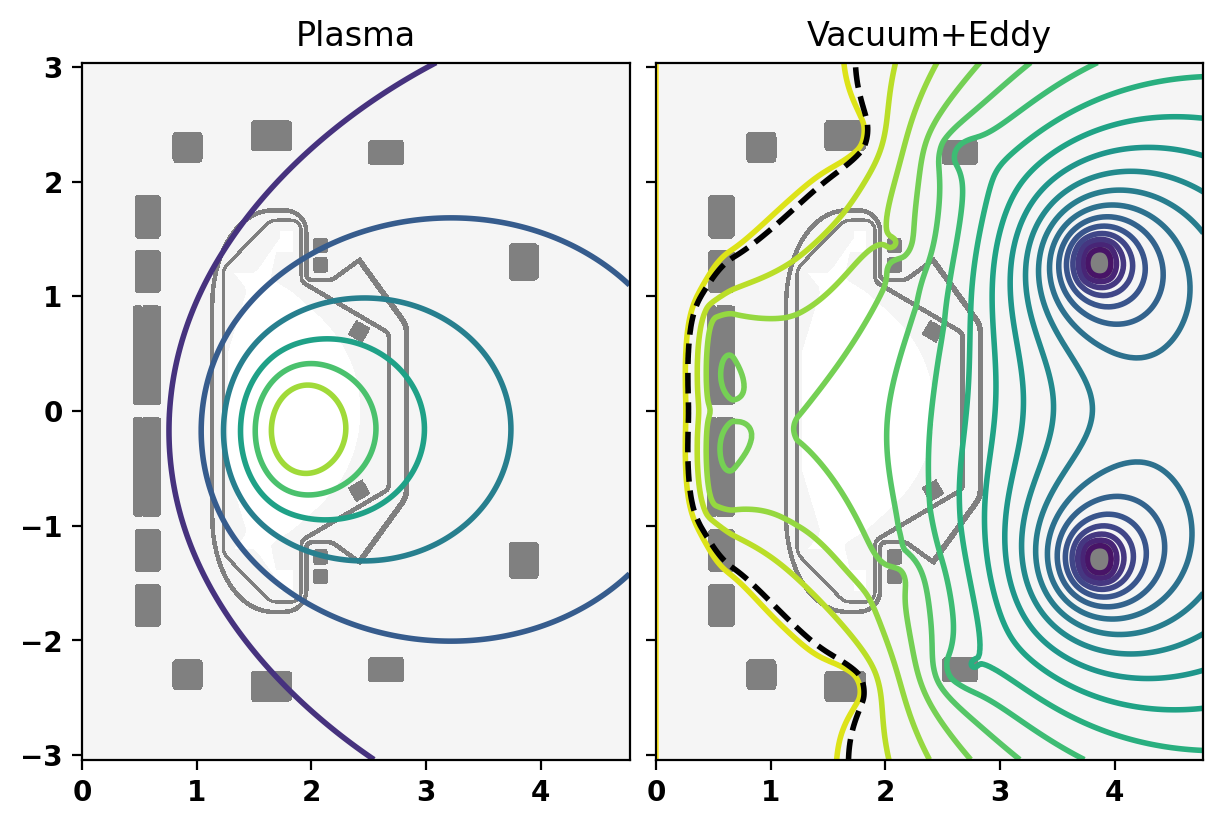

In [15]:
psi_full = mygs.get_psi(normalized=False)
coil_currents, _ = mygs.get_coil_currents()
Jphi_plasma = mygs.calc_jtor_plasma()
mygs.set_coil_currents()
eq_plasma = mygs.vac_solve(rhs_source=Jphi_plasma)
psi_plasma = eq_plasma.get_psi(normalized=False)
psi_vac = psi_full-psi_plasma
mygs.set_coil_currents(coil_currents)
eq_coils = mygs.vac_solve()
psi_coils = eq_coils.get_psi(normalized=False)
psi_eddy = psi_vac - psi_coils

# Plot isolated plasma flux
fig, ax = plt.subplots(1,2,sharey=True,constrained_layout=True)
mygs.plot_machine(fig,ax[0],limiter_color=None)
mygs.plot_psi(fig,ax[0],psi=psi_plasma,normalized=False,xpoint_color=None,opoint_color=None)
ax[0].set_title('Plasma')
mygs.plot_machine(fig,ax[1],coil_colormap=None,limiter_color=None)
mygs.plot_psi(fig,ax[1],psi=psi_vac,normalized=False,plasma_nlevels=20,vacuum_levels=None,xpoint_color=None,opoint_color=None)
mygs.plot_psi(fig,ax[1],psi=psi_vac,normalized=False,plasma_levels=[psi_lim],plasma_color='k',vacuum_levels=None,xpoint_color=None,opoint_color=None)
_ = ax[1].set_title('Vacuum+Eddy')

In [16]:
# Set linear CQ time
CQ_time = 3.0E-3

# Setup simulation
psi_last = psi_eddy.copy()
t = 0.0
dt = CQ_time/20.0
results_CQ = [psi_coils+psi_eddy+psi_plasma]
times_CQ = [0.0]
mygs.settings.pm=False
mygs.update_settings()
mygs.set_coil_currents()
for i in range(150):
    if i == 40:
        dt = CQ_time/5.0
    # Set source from last time step w/ or w/o CQ source
    if t <= CQ_time:
        mygs.set_psi_dt(psi_plasma*dt/CQ_time+psi_last,dt)
    else:
        mygs.set_psi_dt(psi_last,dt)
    
    # Compute next time step
    eq_last = mygs.vac_solve()
    psi_last = eq_last.get_psi(False)
    t += dt
    
    # Save timestep for plotting
    results_CQ.append(psi_coils+psi_last+psi_plasma*max(0.0,1.0-t/CQ_time))
    times_CQ.append(t)
# Convert to NumPy array
times_CQ = np.array(times_CQ)

# Get index of sampling times
ind_sample = (abs(times_CQ-CQ_time/2.0)).argmin()
ind_sample2 = (abs(times_CQ-CQ_time*2.0)).argmin()

### Plot results

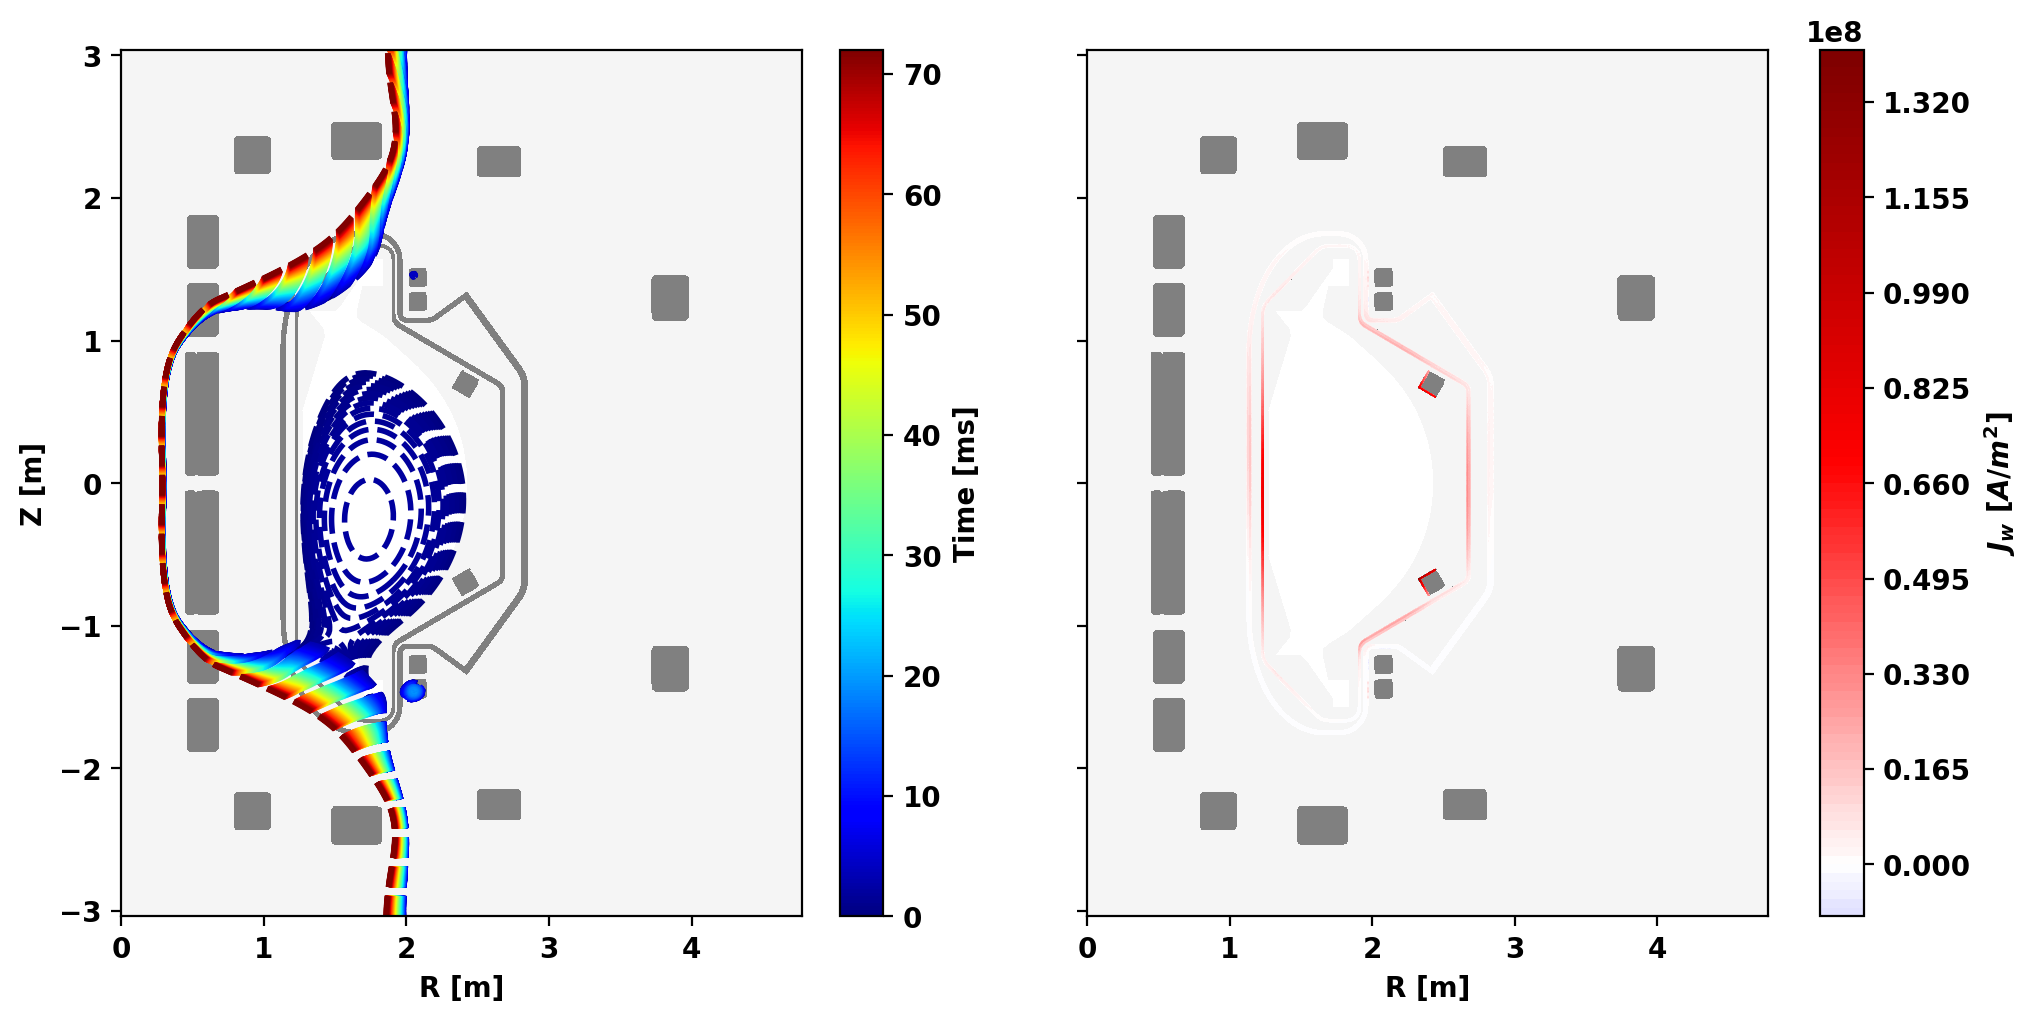

In [17]:
fig, ax = plt.subplots(1,2,sharey=True,figsize=(10,5),constrained_layout=True)

# Plot flux evolution in time
mygs.plot_machine(fig,ax[0],coil_colormap=None,limiter_color=None)
colors = plt.cm.jet(times_CQ/times_CQ[-1])
for i, result in enumerate(results_CQ):
    mygs.plot_psi(fig,ax[0],psi=result,normalized=False,plasma_levels=[psi_lim],plasma_color=[colors[i]],vacuum_levels=None,xpoint_color=None,opoint_color=None)
norm = mpl.colors.Normalize(vmin=0.0, vmax=times_CQ[-1]*1.E3)
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=plt.cm.jet),ax=ax[0],label='Time [ms]')

# Plot snapshot at t=1.5 ms
mygs.plot_machine(fig,ax[1],coil_colormap=None,limiter_color=None)
mygs.plot_eddy(fig,ax[1],psi=results_CQ[ind_sample],colormap='seismic',symmap=True,nlevels=100)

# Format plots
ax[0].set_ylabel('Z [m]')
ax[0].set_xlabel('R [m]')
_ = ax[-1].set_xlabel('R [m]')

### Plot loop voltage

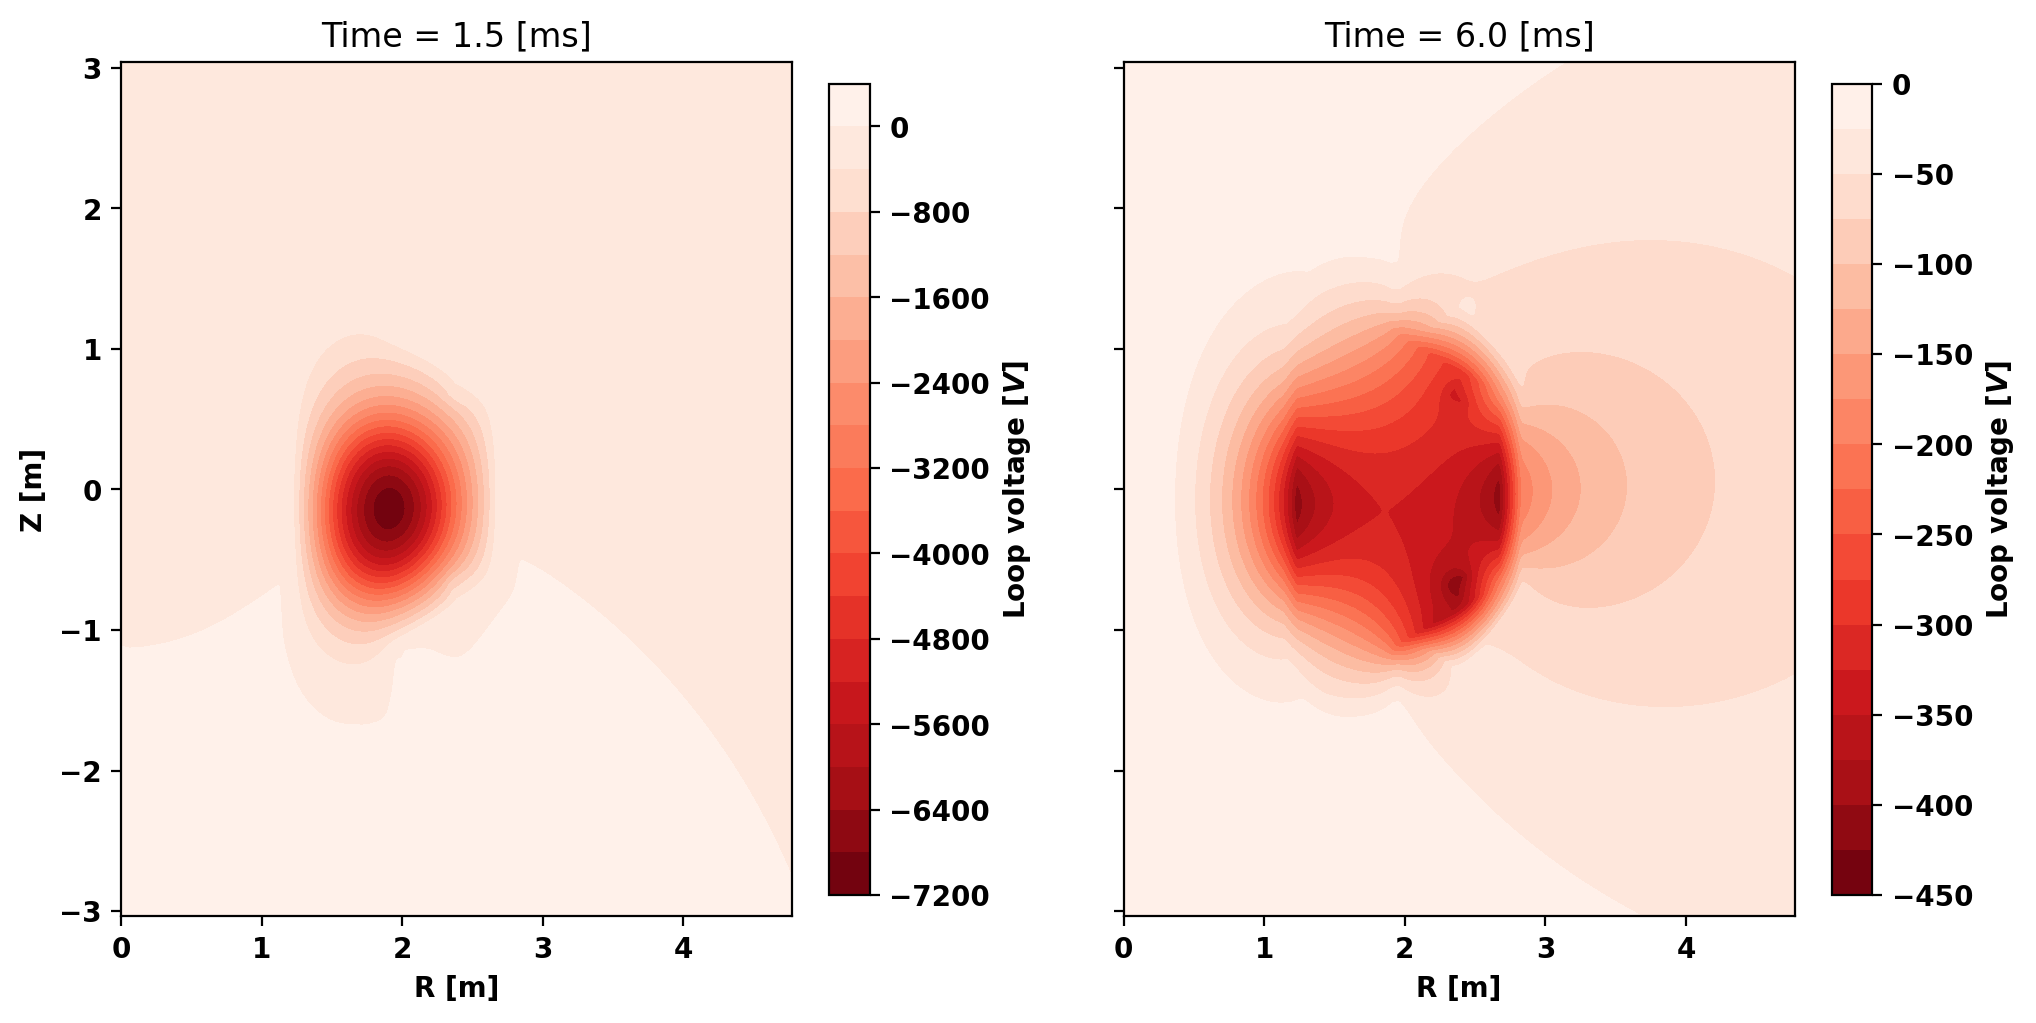

In [18]:
fig, ax = plt.subplots(1,2,figsize=(10,5),sharey=True,constrained_layout=True)

# Plot at t = 1.5 ms
dpsi_dt = (results_CQ[ind_sample+1]-results_CQ[ind_sample-1])/(times_CQ[ind_sample+1]-times_CQ[ind_sample-1])
clf = ax[0].tricontourf(mygs.r[:,0],mygs.r[:,1],mygs.lc,2.0*np.pi*dpsi_dt,levels=20,cmap='Reds_r')
fig.colorbar(clf,ax=ax[0],label=r'Loop voltage [$V$]', shrink=0.95)
ax[0].set_title('Time = {0:.1f} [ms]'.format(times_CQ[ind_sample]*1.E3))

# Plot at t = 6 ms
dpsi_dt = (results_CQ[ind_sample2+1]-results_CQ[ind_sample2-1])/(times_CQ[ind_sample2+1]-times_CQ[ind_sample2-1])
clf = ax[1].tricontourf(mygs.r[:,0],mygs.r[:,1],mygs.lc,2.0*np.pi*dpsi_dt,levels=20,cmap='Reds_r')
fig.colorbar(clf,ax=ax[1],label=r'Loop voltage [$V$]', shrink=0.95)
ax[1].set_title('Time = {0:.1f} [ms]'.format(times_CQ[ind_sample2]*1.E3))

# Format plots
ax[0].set_ylabel('Z [m]')
ax[0].set_xlabel('R [m]')
_ = ax[1].set_xlabel('R [m]')
for ax_tmp in ax:
    ax_tmp.set_aspect('equal','box')

### Compute and plot forces

In [19]:
results_total = [result.get_psi(False) for result in results] + results_CQ
time_total = np.array(times + (times_CQ+times[-1]).tolist())
Fr_inner = np.zeros((len(results_total),))
Fr_outer = np.zeros((len(results_total),))
Fz_inner = np.zeros((len(results_total),))
Fz_outer = np.zeros((len(results_total),))
for i, result in enumerate(results_total):
    mesh_currents, Bv_cond, mask, rcc = compute_forces_components(mygs,result)
    Fr_inner[i] = np.pi*2.0*mygs.compute_area_integral(mesh_currents*mygs.r[:,0]*Bv_cond[:,2],reg_mask=cond_dict['VESSEL_INNER']['reg_id'])
    Fr_outer[i] = np.pi*2.0*mygs.compute_area_integral(mesh_currents*mygs.r[:,0]*Bv_cond[:,2],reg_mask=cond_dict['VESSEL_OUTER']['reg_id'])
    #
    Fz_inner[i] = np.pi*2.0*mygs.compute_area_integral(mesh_currents*mygs.r[:,0]*Bv_cond[:,0],reg_mask=cond_dict['VESSEL_INNER']['reg_id'])
    Fz_outer[i] = np.pi*2.0*mygs.compute_area_integral(mesh_currents*mygs.r[:,0]*Bv_cond[:,0],reg_mask=cond_dict['VESSEL_OUTER']['reg_id'])

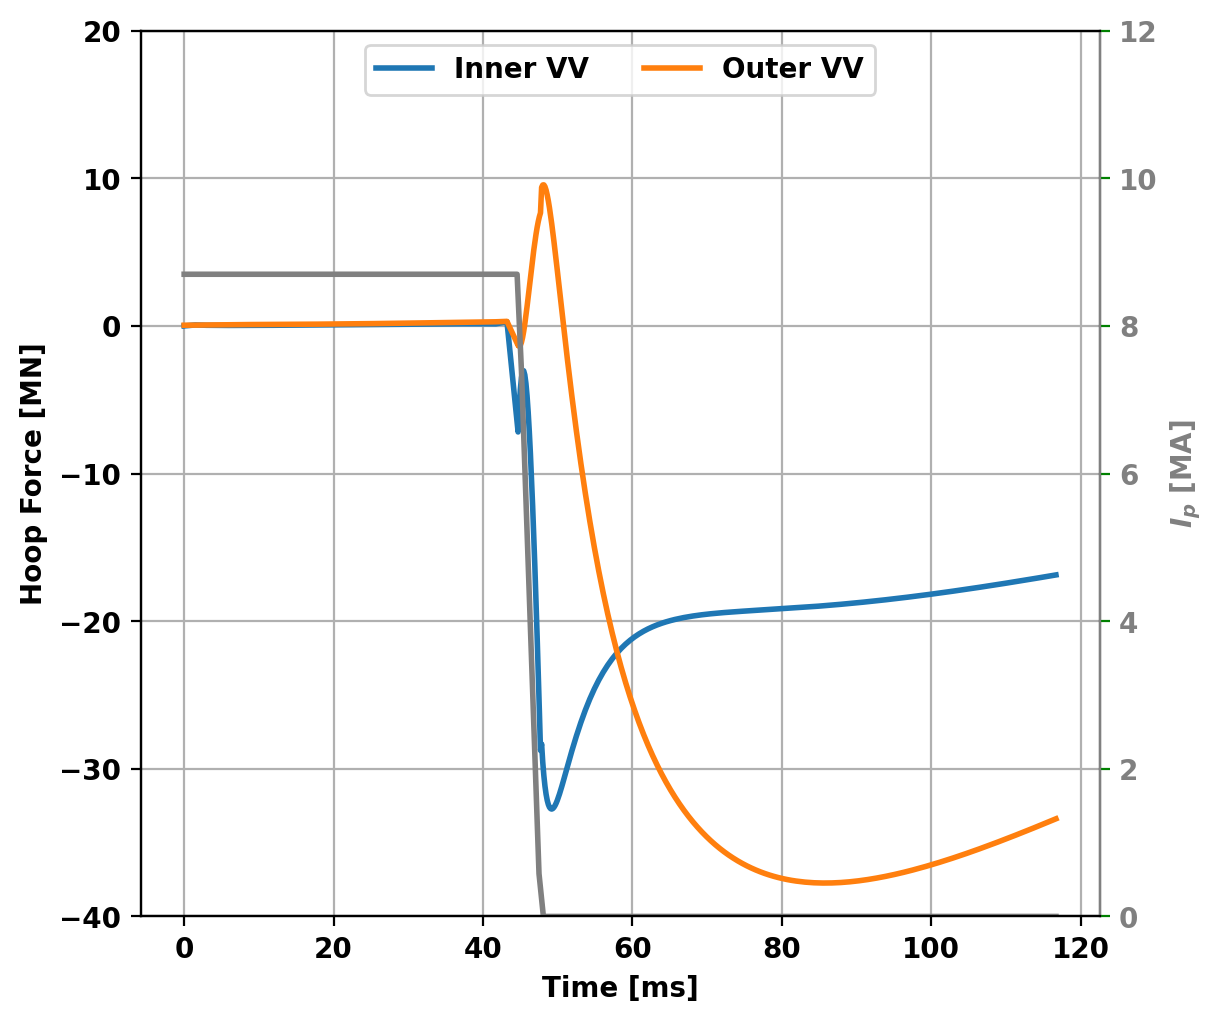

In [20]:
fig, ax = plt.subplots(1,1,figsize=(6,5),constrained_layout=True)

# Plot plasma current
x = np.linspace(0.0,time_total[-1]*1.E3,200)-times[-1]*1.E3
y = np.zeros_like(x); y[x<CQ_time*1.E3] = (CQ_time*1.E3-x[x<CQ_time*1.E3])*abs(eqdsk['ip'])/1.E6/(CQ_time*1.E3); y[y>abs(eqdsk['ip'])/1.E6] = abs(eqdsk['ip'])/1.E6
x += times[-1]*1.E3
ax2 = ax.twinx()
ax2.plot(x,y,label=r'$I_P$',color='0.5')

# Plot forces
ax.plot(time_total*1.E3,np.asarray(Fr_inner)/1.E6,label='Inner VV')
ax.plot(time_total*1.E3,np.asarray(Fr_outer)/1.E6,label='Outer VV')

# Format plot
ax.grid(True)
ax.set_ylim(-40,20)
ax2.set_ylim(0,12)
ax.legend(loc='upper center',ncol=3)
ax.set_ylabel(r'Hoop Force [MN]')
ax2.set_ylabel(r'$I_p$ [MA]',color='0.5')
ax2.tick_params(color='green', labelcolor='0.5')
ax2.spines['right'].set_edgecolor('0.5')
_ = ax.set_xlabel(r'Time [ms]')

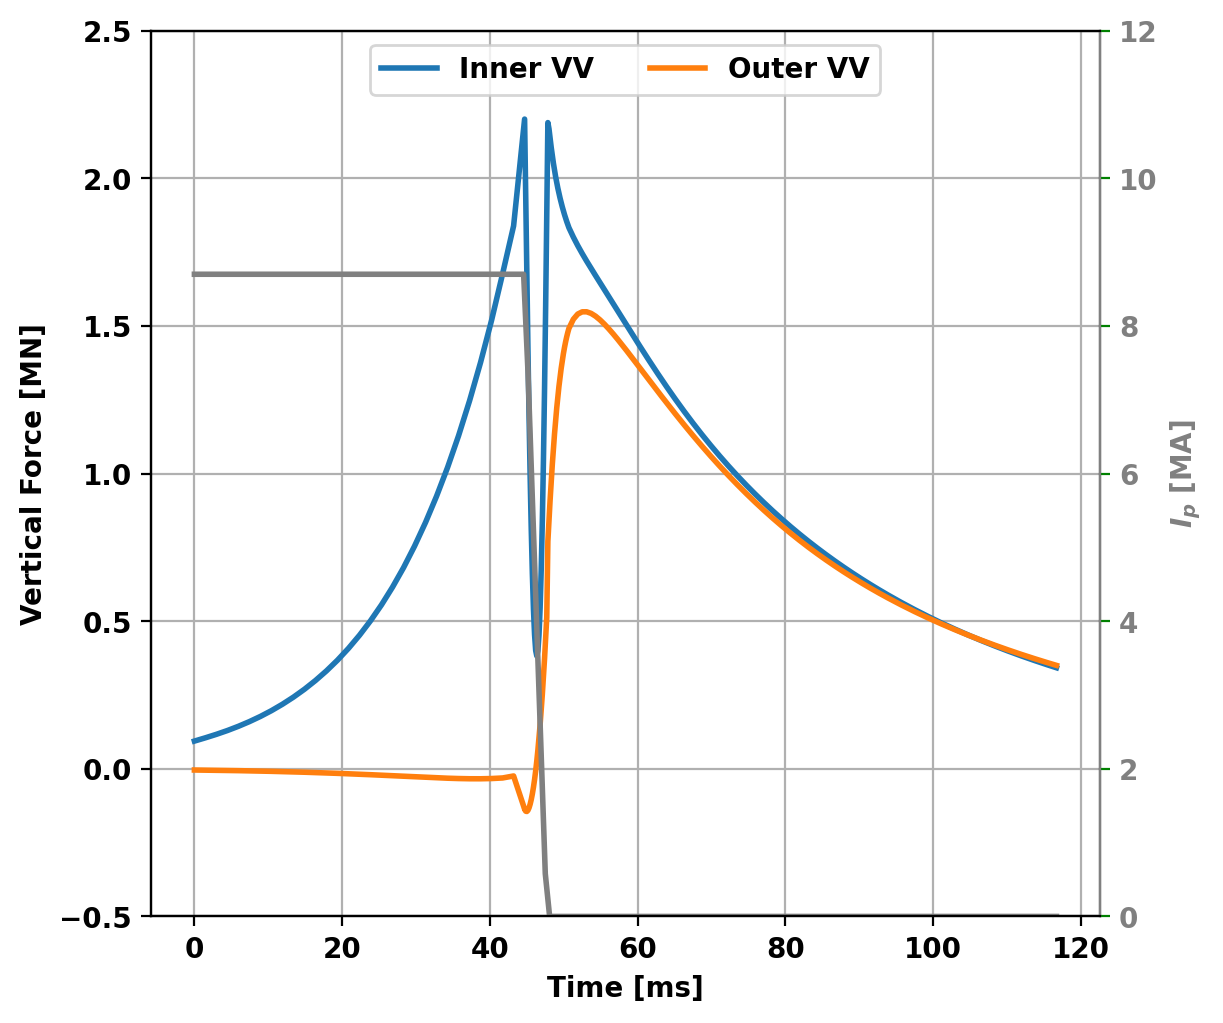

In [21]:
fig, ax = plt.subplots(1,1,figsize=(6,5),constrained_layout=True)

# Plot plasma current
x = np.linspace(0.0,time_total[-1]*1.E3,200)-times[-1]*1.E3
y = np.zeros_like(x); y[x<CQ_time*1.E3] = (CQ_time*1.E3-x[x<CQ_time*1.E3])*abs(eqdsk['ip'])/1.E6/(CQ_time*1.E3); y[y>abs(eqdsk['ip'])/1.E6] = abs(eqdsk['ip'])/1.E6
x += times[-1]*1.E3
ax2 = ax.twinx()
ax2.plot(x,y,label=r'$I_P$',color='0.5')

# Plot forces
ax.plot(time_total*1.E3,np.asarray(Fz_inner)/1.E6,label='Inner VV')
ax.plot(time_total*1.E3,np.asarray(Fz_outer)/1.E6,label='Outer VV')
# ax.plot(time_total*1.E3,-(np.asarray(Fz_inner)+np.asarray(Fz_outer))/1.E6,'k',label='Total')

# Format plot
ax.grid(True)
ax.set_ylim(-0.5,2.5)
ax2.set_ylim(0,12)
ax.legend(loc='upper center',ncol=3)
ax.set_ylabel(r'Vertical Force [MN]')
ax2.set_ylabel(r'$I_p$ [MA]',color='0.5')
ax2.tick_params(color='green', labelcolor='0.5')
ax2.spines['right'].set_edgecolor('0.5')
_ = ax.set_xlabel(r'Time [ms]')

In [22]:
def plot_CQ(fig, ax, psi, time):
    # Get currents and field in conducting regions
    J_cond, Bv_cond, mask, rcc = compute_forces_components(mygs,psi,cell_centered=True)
    
    # Plot current density
    Jphi = J_cond[mask]
    Jphi /= 1.E6
    vmax = max(1.E0,abs(Jphi).max())
    mygs.plot_psi(fig,ax[0],psi=psi,normalized=False,plasma_levels=[psi_lim],plasma_color=['0.5'],vacuum_levels=None,xpoint_color=None,opoint_color=None)
    clf2 = ax[0].tripcolor(mygs.r[:,0],mygs.r[:,1],mygs.lc[mask],Jphi,cmap='Reds', vmin=0.0, vmax=vmax)
    cb1 = fig.colorbar(clf2,ax=ax[0],label=r'Toroidal Current Density [$MA/m^2$]',format='{x:6.1f}',shrink=0.95)
    
    # Radial force
    Fr = J_cond[mask]*Bv_cond[mask,2]
    Fr /= 1.E6
    vmax = abs(Fr).max()
    mygs.plot_psi(fig,ax[1],psi=psi,normalized=False,plasma_levels=[psi_lim],plasma_color=['0.5'],vacuum_levels=None,xpoint_color=None,opoint_color=None)
    clf = ax[1].tripcolor(mygs.r[:,0],mygs.r[:,1],mygs.lc[mask],Fr,cmap='seismic', vmin=-vmax, vmax=vmax)
    cb2 = fig.colorbar(clf,ax=ax[1],label=r'Radial Force per unit volume [$MN/m^3$]', shrink=0.95)
    
    # Vertical force
    Fz = -J_cond[mask]*Bv_cond[mask,0]
    Fz /= 1.E6
    vmax = abs(Fz).max()
    mygs.plot_psi(fig,ax[2],psi=psi,normalized=False,plasma_levels=[psi_lim],plasma_color=['0.5'],vacuum_levels=None,xpoint_color=None,opoint_color=None)
    clf = ax[2].tripcolor(mygs.r[:,0],mygs.r[:,1],mygs.lc[mask],Fz,cmap='seismic', vmin=-vmax, vmax=vmax)
    cb3 = fig.colorbar(clf,ax=ax[2],label=r'Vertical Force per unit volume [$MN/m^3$]', shrink=0.95)
    
    # Format plots
    fig.suptitle('Time = {0:.1f} [ms]'.format(time*1.E3),fontsize=20)
    ax[0].set_ylabel('Z [m]')
    ax[0].set_xlabel('R [m]')
    _ = ax[1].set_xlabel('R [m]')
    for ax_tmp in ax:
        ax_tmp.set_aspect('equal','box')

    return cb1, cb2, cb3

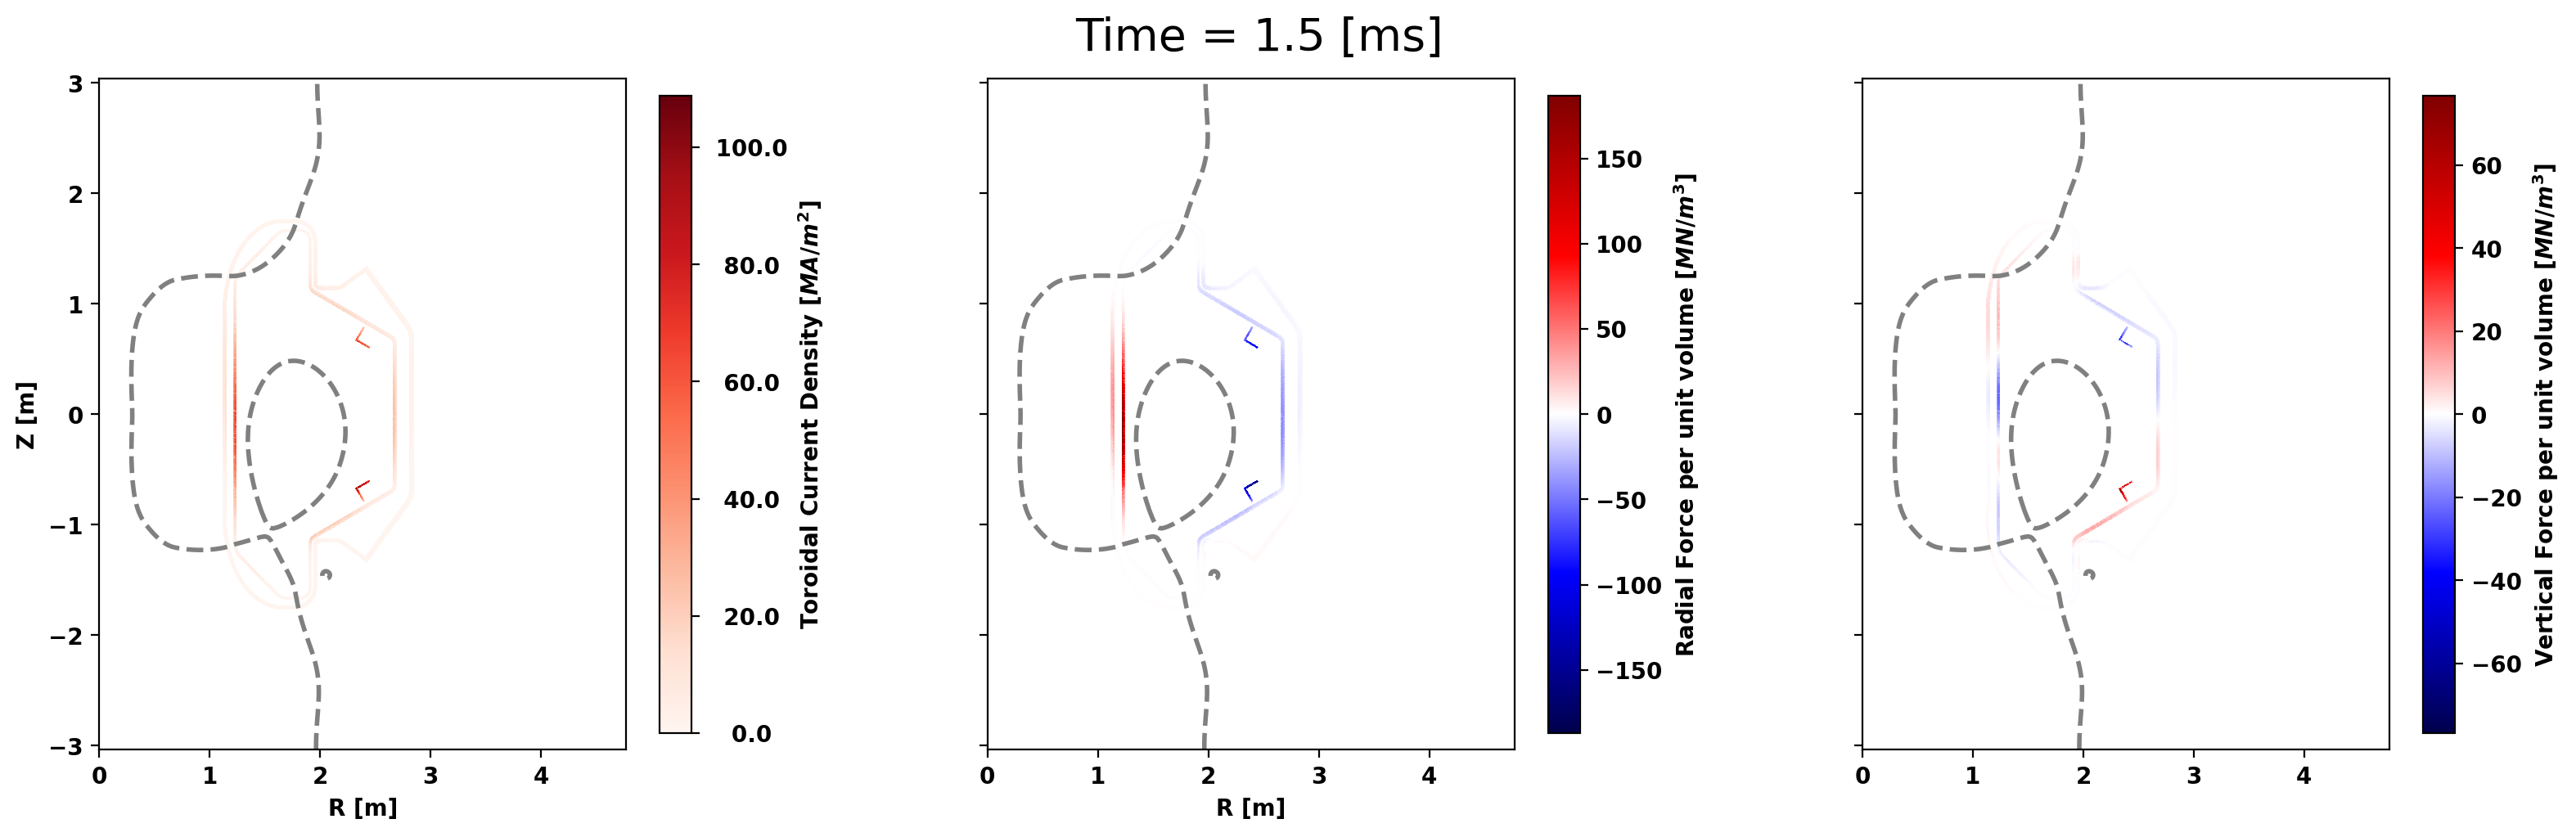

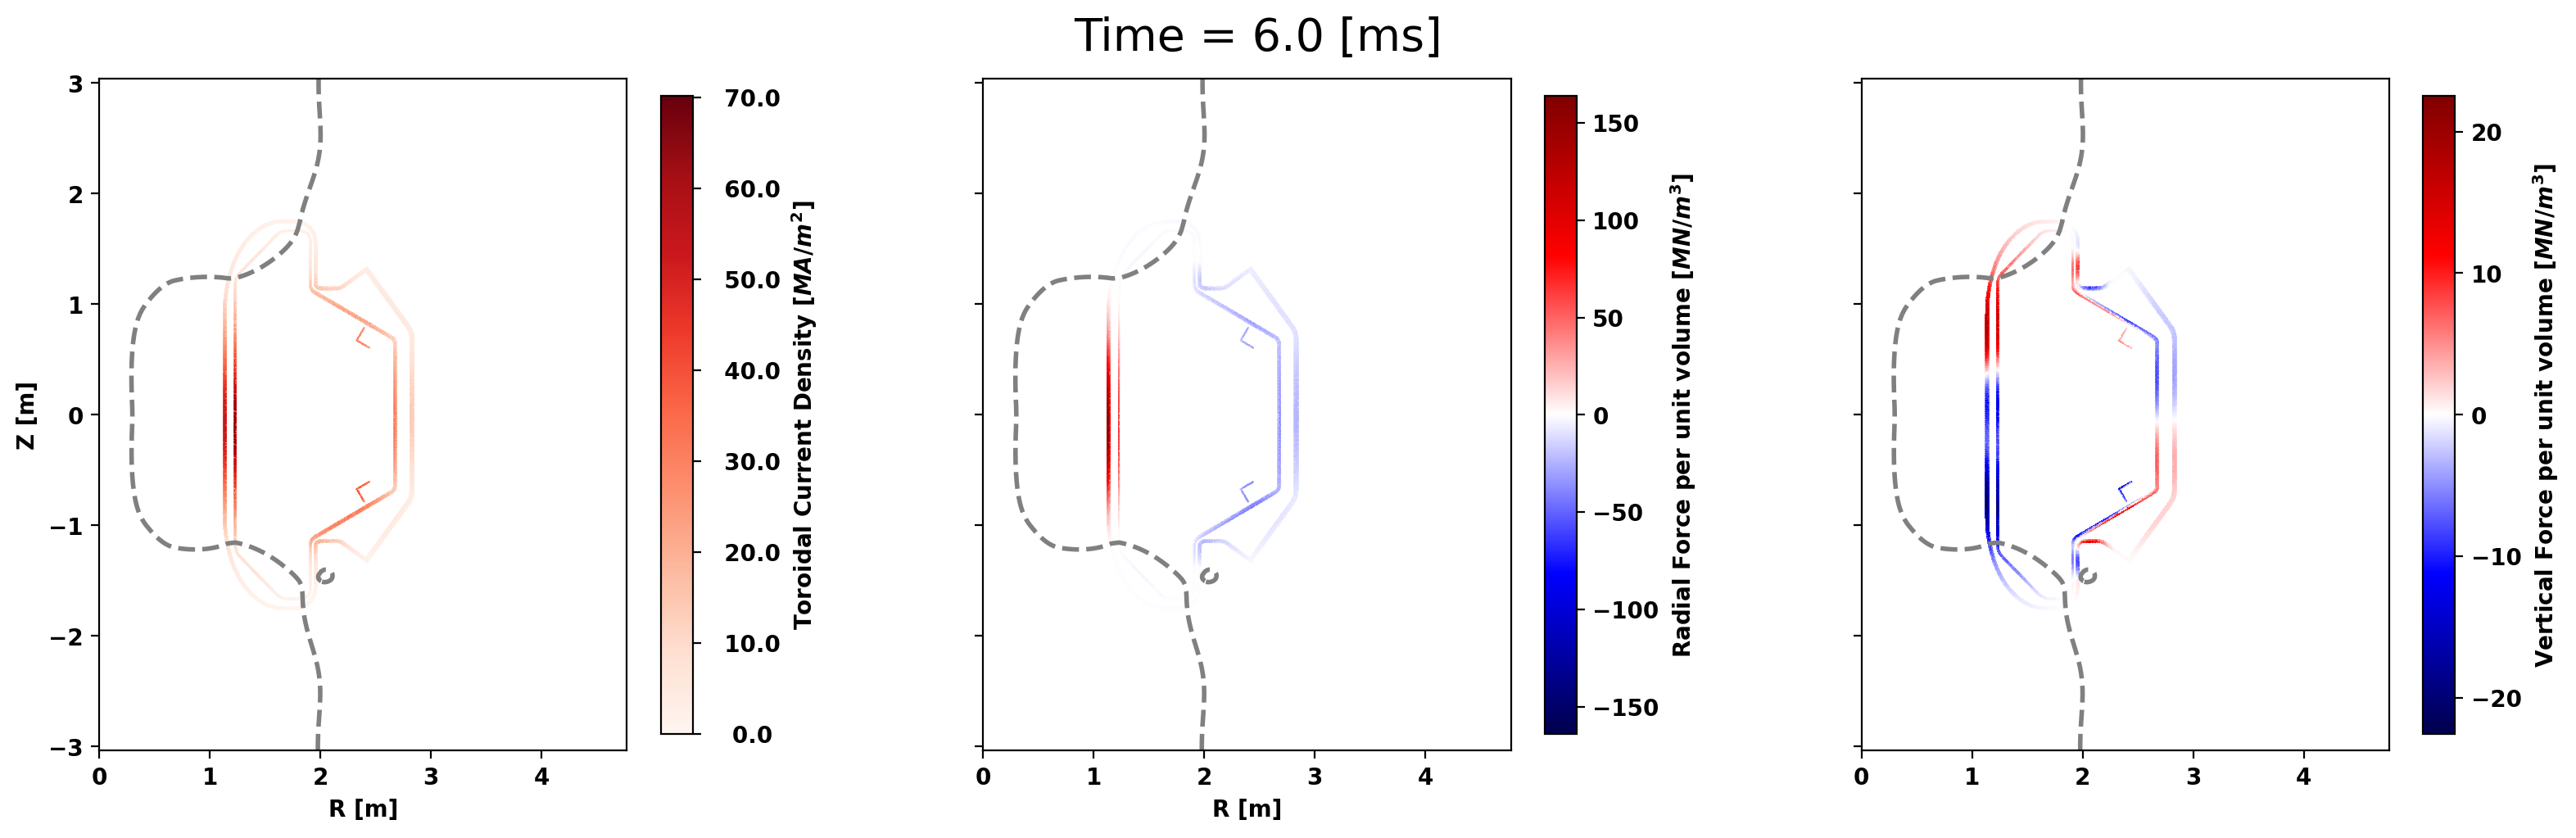

In [23]:
# Plot results
fig, ax = plt.subplots(1,3,figsize=(16,5),sharey=True,constrained_layout=True)
_ = plot_CQ(fig, ax, results_CQ[ind_sample], times_CQ[ind_sample])

fig, ax = plt.subplots(1,3,figsize=(16,5),sharey=True,constrained_layout=True)
_ = plot_CQ(fig, ax, results_CQ[ind_sample2], times_CQ[ind_sample2])

### Create animation of simulation

In [24]:
import matplotlib.animation
from IPython.display import HTML

fig, ax = plt.subplots(1,3,figsize=(16,5),sharey=True,constrained_layout=True)
cbs = [None, None, None]

def animate(ii):
    # Clear figure
    global cbs
    for cb in cbs:
        if cb is not None:
            cb.remove()
    for ax_tmp in ax:
        ax_tmp.clear()

    # Plot time point
    cbs[0], cbs[1], cbs[2] = plot_CQ(fig, ax, results_total[ii], times[ii])


ani = matplotlib.animation.FuncAnimation(fig, animate, frames=len(times))
plt.close(fig)

In [25]:
# Embed in Jupyter
# HTML(ani.to_jshtml())

# Save as GIF
# ani.save('SPARC_CQ.gif',dpi=200,fps=10)

In [26]:
fig, ax = plt.subplots(1,3,figsize=(16,5),sharey=True,constrained_layout=True)
cbs = [None, None, None]

def animate(ii):
    # Clear figure
    global cbs
    for cb in cbs:
        if cb is not None:
            cb.remove()
    for ax_tmp in ax:
        ax_tmp.clear()

    # Plot time point
    cbs[0], cbs[1], cbs[2] = plot_CQ(fig, ax, results_CQ[ii], times_CQ[ii])


ani = matplotlib.animation.FuncAnimation(fig, animate, frames=40)
plt.close(fig)

/usr/local/Python_venv/OFT_env/lib/python3.14/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


In [27]:
# Embed in Jupyter
# HTML(ani.to_jshtml())

# Save as GIF
# ani.save('SPARC_CQ.gif',dpi=200,fps=10)